<a href="https://colab.research.google.com/github/JOhnsonKC201/Microsoft-4B-groundwater-timeseries-prediction-using-AI/blob/main/notebooks/data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading the Data

In [ ]:
!git clone https://github.com/Break-Through-Tech/Microsoft-4B-groundwater-timeseries-prediction-using-AI.git

Cloning into 'Microsoft-4B-groundwater-timeseries-prediction-using-AI'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 40 (delta 16), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 7.03 MiB | 7.73 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [ ]:
%cd Microsoft-4B-groundwater-timeseries-prediction-using-AI

/content/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks/Microsoft-4B-groundwater-timeseries-prediction-using-AI


In [ ]:
%cd notebooks

/content/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks/Microsoft-4B-groundwater-timeseries-prediction-using-AI/notebooks


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Daily Dataset

In [ ]:
df_daily = pd.read_csv("/content/Microsoft-4B-groundwater-timeseries-prediction-using-AI/data/svn_regional_53_wells_daily_2019_2023.csv")
df_daily.head()

/tmp/ipykernel_3102/3712712724.py:1: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  df_daily = pd.read_csv("/content/Microsoft-4B-groundwater-timeseries-prediction-using-AI/data/svn_regional_53_wells_daily_2019_2023.csv")


,GROW_ID,interval,date,year,month,aggregated_from_n_values,outliers_change_points,plateaus,groundwater_water_level_elevation_m_asl,precipitation_mswep_mm_year-1,...,permeability_0-100_m_m-2,total_porosity_0-100_m_fraction,soil_texture_0-30_cm_class,soil_texture_30-200_cm_class,soil_saturated_conductivity_0-30_cm_cm_d-1,soil_saturated_conductivity_30-200_cm_cm_d-1,distance_perennial_streams_m,drainage_density_m-1,main_landuse_class,distance_to_cluster_center_km
0,GROW-18108201772,d,2019-01-01,2019,2019-01,NaN,False,0,304.83,45.625,...,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
1,GROW-18108201772,d,2019-01-02,2019,2019-01,NaN,False,0,304.79,0.000,...,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
2,GROW-18108201772,d,2019-01-03,2019,2019-01,NaN,False,0,304.73,0.000,...,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
3,GROW-18108201772,d,2019-01-04,2019,2019-01,NaN,False,0,304.68,0.000,...,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858
4,GROW-18108201772,d,2019-01-05,2019,2019-01,NaN,False,0,304.64,0.000,...,3.019952e-11,0.22,Fine,Medium,5.8697,3.4658,4100.0,0.00031,forests_and_natural_vegetation,17.231858


In [ ]:
df_daily.shape

(96778, 65)

In [ ]:
df_daily.dtypes

,0
GROW_ID,object
interval,object
date,object
year,int64
month,object
...,...
soil_saturated_conductivity_30-200_cm_cm_d-1,float64
distance_perennial_streams_m,float64
drainage_density_m-1,float64
main_landuse_class,object


## Daily Dataset Cleaning

In [ ]:
# missing data for daily set

null_counts = df_daily.isnull().sum()
result = null_counts[null_counts > 0]

In [ ]:
nan_col_types = df_daily[result.index].dtypes
nan_col_types

# What data types are missing in the daily dataset?

,0
aggregated_from_n_values,float64
groundwater_water_level_elevation_m_asl,float64
precipitation_gpcc_mm_year-1,float64
ndvi_ratio,float64
withdrawal_industrial_m3_year-1,float64
withdrawal_domestic_m3_year-1,float64
urban_area_fraction,float64
pastures_fraction,float64
cropland_rainfed_fraction,float64
cropland_irrigated_fraction,float64


In [ ]:
df_daily = df_daily.drop(columns=['aggregated_from_n_values', 'status', 'aquifer_name', 'confinement'], axis=1)

In [ ]:
dfdaily_missing_cols = df_daily.columns[df_daily.isna().any()]
numeric_cols = df_daily[dfdaily_missing_cols].select_dtypes(include=np.number).columns
df_interpolated = df_daily[numeric_cols].interpolate()
df_daily[numeric_cols] = df_interpolated

In [ ]:
df_daily.columns[df_daily.isna().any()]

Index(['soil_texture_30-200_cm_class'], dtype='object')

In [ ]:
df_daily.shape

(96778, 61)

In [ ]:
# y = groundwater_water_level_elevation_m_asl

## Standardizing Categorical Variables

In [ ]:
# Identify categorical columns
df_daily.select_dtypes(include=['object'])

,GROW_ID,interval,date,month,name,feature_type,purpose,country,organisation,license,starting_date,ending_date,trend_direction,reference_point,koeppen_geiger_class,hydrobelt_class,aquifer_type_class,soil_texture_0-30_cm_class,soil_texture_30-200_cm_class,main_landuse_class
0,GROW-18108201772,d,2019-01-01,2019-01,Mengeš (Mp-0275),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,decreasing,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Fine,Medium,forests_and_natural_vegetation
1,GROW-18108201772,d,2019-01-02,2019-01,Mengeš (Mp-0275),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,decreasing,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Fine,Medium,forests_and_natural_vegetation
2,GROW-18108201772,d,2019-01-03,2019-01,Mengeš (Mp-0275),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,decreasing,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Fine,Medium,forests_and_natural_vegetation
3,GROW-18108201772,d,2019-01-04,2019-01,Mengeš (Mp-0275),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,decreasing,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Fine,Medium,forests_and_natural_vegetation
4,GROW-18108201772,d,2019-01-05,2019-01,Mengeš (Mp-0275),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2004-01-01,2023-12-31,decreasing,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Fine,Medium,forests_and_natural_vegetation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96773,GROW-18112547287,d,2023-12-27,2023-12,Lj - Sojerjeva (0631),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2012-01-01,2023-12-31,no trend,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Medium,NaN,forests_and_natural_vegetation
96774,GROW-18112547287,d,2023-12-28,2023-12,Lj - Sojerjeva (0631),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2012-01-01,2023-12-31,no trend,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Medium,NaN,forests_and_natural_vegetation
96775,GROW-18112547287,d,2023-12-29,2023-12,Lj - Sojerjeva (0631),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2012-01-01,2023-12-31,no trend,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Medium,NaN,forests_and_natural_vegetation
96776,GROW-18112547287,d,2023-12-30,2023-12,Lj - Sojerjeva (0631),Water well,Observation / monitoring,SVN,"Slovenia - MINISTRY OF THE ENVIRONMENT, CLIMAT...",Attribution 4.0 International (CC BY 4.0),2012-01-01,2023-12-31,no trend,Water level elevation a.m.s.l.,Cfb,Mid-latitude,karst,Medium,NaN,forests_and_natural_vegetation


In [ ]:
df_daily[['trend_direction', 'soil_texture_0-30_cm_class', 'soil_texture_30-200_cm_class']].dtypes


,0
trend_direction,object
soil_texture_0-30_cm_class,object
soil_texture_30-200_cm_class,object


In [ ]:
df_daily['trend_direction'].unique()

array(['decreasing', 'no trend'], dtype=object)

In [ ]:
df_daily['soil_texture_0-30_cm_class'].unique()

array(['Fine', 'Medium'], dtype=object)

In [ ]:
df_daily['soil_texture_30-200_cm_class'].unique()

array(['Medium', nan, 'Fine'], dtype=object)

In [ ]:
df_daily_encoded = df_daily.copy()

In [ ]:
# Columns to encode
to_encode = ['trend_direction', 'soil_texture_0-30_cm_class', 'soil_texture_30-200_cm_class']

for column in to_encode:
  # Create dummy columns
  df_daily_temp = pd.get_dummies(df_daily_encoded[column], prefix=column)

  # Add dummy columns to dataset
  df_daily_encoded = df_daily_encoded.join(df_daily_temp)

  # Drop original column
  df_daily_encoded.drop(columns=column, inplace=True)

# Check whether the loop was successful
df_daily_encoded.columns

Index(['GROW_ID', 'interval', 'date', 'year', 'month',
       'outliers_change_points', 'plateaus',
       'groundwater_water_level_elevation_m_asl',
       'precipitation_mswep_mm_year-1', 'precipitation_gpcc_mm_year-1',
       'potential_evapotranspiration_era5_mm_year-1',
       'potential_evapotranspiration_gleam_mm_year-1',
       'actual_evapotranspiration_mm_year-1', 'interception_mm_year-1',
       'air_temperature_°C', 'snow_depth_m',
       'days_with_snow_cover_days_year-1', 'ndvi_ratio',
       'lai_low_vegetation_ratio', 'lai_high_vegetation_ratio',
       'withdrawal_industrial_m3_year-1', 'withdrawal_domestic_m3_year-1',
       'urban_area_fraction', 'pastures_fraction', 'cropland_rainfed_fraction',
       'cropland_irrigated_fraction', 'forests_natural_vegetation_fraction',
       'original_ID_groundwater', 'name', 'feature_type', 'purpose',
       'latitude', 'longitude', 'country', 'organisation', 'license',
       'starting_date', 'ending_date', 'length_years', 'auto

## Daily Feature Engineering

In [ ]:
## feature engineering
# new cols from raw ones so the model sees the pattern (ex: 90 day rain not just today)

In [ ]:
# date to datetime, sort by well + date
df_daily_fe = df_daily_encoded.copy()
df_daily_fe['date'] = pd.to_datetime(df_daily_fe['date'])
df_daily_fe.sort_values(by=['GROW_ID', 'date'], inplace=True)

In [ ]:
# month + recharge season flag (oct-mar), wells fill up in winter
df_daily_fe['month_num'] = df_daily_fe['date'].dt.month
df_daily_fe['is_recharge_season'] = df_daily_fe['month_num'].isin([10, 11, 12, 1, 2, 3]).astype(int)

In [ ]:
# precip mm/year -> mm/day
df_daily_fe['precip_mm'] = df_daily_fe['precipitation_mswep_mm_year-1'] / 365.25

In [ ]:
# rain minus evaporation
df_daily_fe['water_balance_mm'] = df_daily_fe['precip_mm'] - df_daily_fe['actual_evapotranspiration_mm_year-1'] / 365.25

In [ ]:
# rolling sums per well (30 / 90 days) so windows dont mix wells
target = 'groundwater_water_level_elevation_m_asl'
grouped_daily = df_daily_fe.groupby('GROW_ID')

df_daily_fe['precip_sum_30'] = grouped_daily['precip_mm'].transform(lambda x: x.rolling(30, min_periods=1).sum())
df_daily_fe['precip_sum_90'] = grouped_daily['precip_mm'].transform(lambda x: x.rolling(90, min_periods=1).sum())
df_daily_fe['water_balance_sum_90'] = grouped_daily['water_balance_mm'].transform(lambda x: x.rolling(90, min_periods=1).sum())

In [ ]:
# past levels + how much it moved
df_daily_fe['level_lag_1'] = grouped_daily[target].shift(1)
df_daily_fe['level_lag_7'] = grouped_daily[target].shift(7)
df_daily_fe['level_lag_30'] = grouped_daily[target].shift(30)
df_daily_fe['level_diff_7'] = grouped_daily[target].diff(7)

# level vs the well's own avg, wells sit at diff elevations
df_daily_fe['level_anomaly'] = df_daily_fe[target] - df_daily_fe['groundwater_mean_m']

In [ ]:
# drop first rows per well, no history so lags are NaN
df_daily_fe = df_daily_fe.dropna(subset=['level_lag_30'])
print(df_daily_fe.shape)

(95188, 76)


## Daily Visualizations

In [ ]:
df_daily.describe()

,year,plateaus,groundwater_water_level_elevation_m_asl,precipitation_mswep_mm_year-1,precipitation_gpcc_mm_year-1,potential_evapotranspiration_era5_mm_year-1,potential_evapotranspiration_gleam_mm_year-1,actual_evapotranspiration_mm_year-1,interception_mm_year-1,air_temperature_°C,...,groundwater_median_m,ground_elevation_merit_m_asl,topographic_slope_degree,permeability_0-100_m_m-2,total_porosity_0-100_m_fraction,soil_saturated_conductivity_0-30_cm_cm_d-1,soil_saturated_conductivity_30-200_cm_cm_d-1,distance_perennial_streams_m,drainage_density_m-1,distance_to_cluster_center_km
count,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000,...,96778.000000,96778.000000,96778.000000,9.677800e+04,9.677800e+04,96778.000000,96778.000000,96778.000000,96778.000000,96778.000000
mean,2020.999452,0.303147,311.498018,1555.004665,1643.459038,1303.509741,835.811077,647.954636,96.116659,10.967417,...,311.545962,329.809439,0.852264,3.019952e-11,2.200000e-01,11.315557,5.147047,3849.056604,0.000321,13.778551
std,1.414027,1.328863,36.950447,3268.638153,652.341643,1114.782285,634.230614,465.454715,126.457399,7.803753,...,36.977926,46.726883,1.084593,5.235822e-23,4.837822e-14,6.888622,1.933740,1462.187710,0.000025,6.911109
min,2019.000000,0.000000,270.470000,0.000000,90.120000,-16.491157,9.267370,9.089959,0.000000,-11.497070,...,271.670000,281.800020,0.040000,3.019952e-11,2.200000e-01,4.659700,2.883000,700.000000,0.000277,0.000000
25%,2020.000000,0.000000,286.850000,0.000000,1217.554571,441.084140,253.032031,209.397781,0.000043,4.356200,...,286.820000,289.100000,0.250000,3.019952e-11,2.200000e-01,7.061500,3.725900,3100.000000,0.000303,7.711444
50%,2021.000000,0.000000,293.510000,111.210938,1622.436788,1033.764680,718.565900,570.509180,44.857259,10.637400,...,291.130000,311.700000,0.520000,3.019952e-11,2.200000e-01,8.207300,4.525400,3400.000000,0.000310,15.142683
75%,2022.000000,0.000000,334.040000,1383.007812,2081.570365,1798.796942,1317.011615,1037.181628,147.923455,17.878540,...,334.130000,360.800020,0.820000,3.019952e-11,2.200000e-01,9.845500,5.282400,4700.000000,0.000342,20.052990
max,2023.000000,16.000000,474.200000,34492.500000,5774.400000,8466.665195,3237.025130,2494.164355,1130.846285,29.818500,...,470.850000,505.500000,5.710000,3.019952e-11,2.200000e-01,28.842800,10.684700,7700.000000,0.000372,24.394951


In [ ]:
# What features are highly correlated with each other?
numeric_cols = df_daily.select_dtypes(include=[np.number]).columns
corr_matrix = df_daily[numeric_cols].corr()
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print(corr_pairs.head(20))

groundwater_mean_m                            groundwater_median_m                            0.999939
groundwater_median_m                          groundwater_mean_m                              0.999939
groundwater_water_level_elevation_m_asl       groundwater_mean_m                              0.998970
groundwater_mean_m                            groundwater_water_level_elevation_m_asl         0.998970
groundwater_median_m                          groundwater_water_level_elevation_m_asl         0.998913
groundwater_water_level_elevation_m_asl       groundwater_median_m                            0.998913
withdrawal_domestic_m3_year-1                 urban_area_fraction                             0.994692
urban_area_fraction                           withdrawal_domestic_m3_year-1                   0.994692
soil_saturated_conductivity_30-200_cm_cm_d-1  soil_saturated_conductivity_0-30_cm_cm_d-1      0.982725
soil_saturated_conductivity_0-30_cm_cm_d-1    soil_saturated_conductivity

In [ ]:
# 53 unique well ID's
df_daily_fe['original_ID_groundwater'].nunique()

53

In [ ]:
df_daily_fe['original_ID_groundwater'].unique()

array([ 1173,  1178,  1179,  1181,  1183,  1184,  1186,  1188,  1189,
        1190,  1192,  1193,  1195,  1197,  1199,  1200,  1201,  1203,
        1206, 12066, 12067, 12068, 12069,  1207, 12070, 12071, 12072,
       12073, 12086, 12088, 12089, 12090, 12093, 12096, 12097, 12098,
       16627, 16628, 16629, 16630, 16631, 16632,   192,   656,  6566,
        8103,  8122,  8123,  8145,  8153,  8179,  8307,  9826])

In [ ]:
df_daily_fe.head()

,GROW_ID,interval,date,year,month,outliers_change_points,plateaus,groundwater_water_level_elevation_m_asl,precipitation_mswep_mm_year-1,precipitation_gpcc_mm_year-1,...,precip_mm,water_balance_mm,precip_sum_30,precip_sum_90,water_balance_sum_90,level_lag_1,level_lag_7,level_lag_30,level_diff_7,level_anomaly
30,GROW-18108201772,d,2019-01-31,2019,2019-01,False,0,303.41,205.3125,821.04,...,0.562115,0.407358,65.517625,65.642539,54.283558,303.45,303.69,304.83,-0.28,-2.474637
31,GROW-18108201772,d,2019-02-01,2019,2019-02,False,0,303.38,6410.3125,1111.92,...,17.550479,17.236973,83.068104,83.193018,71.520530,303.41,303.64,304.79,-0.26,-2.504637
32,GROW-18108201772,d,2019-02-02,2019,2019-02,False,0,303.34,17748.1250,1111.92,...,48.591718,48.004336,131.659822,131.784736,119.524866,303.38,303.61,304.73,-0.27,-2.544637
33,GROW-18108201772,d,2019-02-03,2019,2019-02,False,0,303.32,6387.5000,1111.92,...,17.488022,17.113334,149.147844,149.272758,136.638200,303.34,303.57,304.68,-0.25,-2.564637
34,GROW-18108201772,d,2019-02-04,2019,2019-02,False,0,303.39,0.0000,1111.92,...,0.000000,-0.324305,149.147844,149.272758,136.313896,303.32,303.52,304.64,-0.13,-2.494637


(array([6.8520e+03, 1.0884e+04, 2.1290e+03, 3.7890e+03, 2.3282e+04,
        9.5100e+02, 2.9940e+03, 1.6600e+03, 1.0290e+03, 2.1900e+02,
        9.1000e+01, 1.5790e+03, 1.7870e+03, 1.8300e+03, 4.2240e+03,
        1.0102e+04, 5.0270e+03, 4.5430e+03, 1.4210e+03, 3.1770e+03,
        1.5790e+03, 4.5600e+02, 1.8600e+02, 9.0000e+00, 0.0000e+00,
        0.0000e+00, 1.3530e+03, 2.2300e+03, 9.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.5300e+02, 1.6430e+03]),
 array([270.47  , 274.5446, 278.6192, 282.6938, 286.7684, 290.843 ,
        294.9176, 298.9922, 303.0668, 307.1414, 311.216 , 315.2906,
        319.3652, 323.4398, 327.5144, 331.589 , 335.6636, 339.7382,
        343.8128, 347.8874, 351.962 , 356.0366, 360.1112, 364.1858,
        368.2604, 372.335 , 376.4096, 380.4842

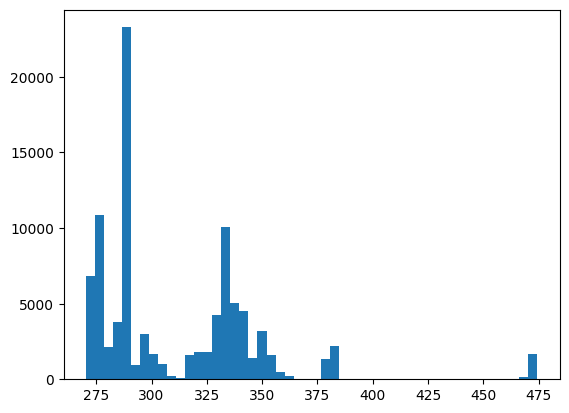

In [ ]:
plt.hist(x='groundwater_water_level_elevation_m_asl', data=df_daily_fe, bins=50)

{'whiskers': [<matplotlib.lines.Line2D at 0x7e761259a210>,
 'caps': [<matplotlib.lines.Line2D at 0x7e761259a490>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e761259a0d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7e761259a710>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e761259a850>],
 'means': []}

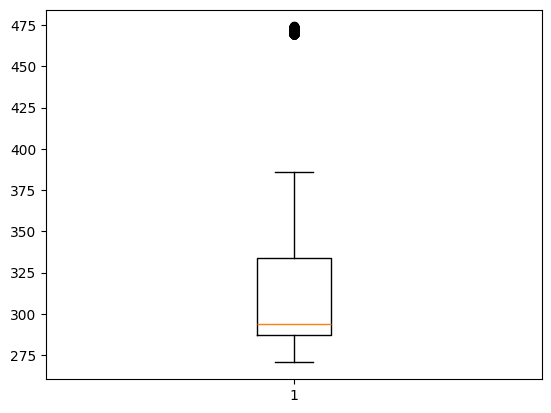

In [ ]:
# There seems to be several outliers around the value of 475
plt.boxplot(x='groundwater_water_level_elevation_m_asl', data=df_daily_fe)

In [ ]:
# All observations with 'groundwater_water_level_elevation_m_asl' greater than 400
water_level_outliers = df_daily_fe[df_daily_fe['groundwater_water_level_elevation_m_asl'] > 400]
# Number of unique well ID's in the subset of data: 1
print(water_level_outliers['original_ID_groundwater'].nunique())
# The outliers can all be attributed to one well: 12071
print(water_level_outliers['original_ID_groundwater'].unique())

1
[12071]


# Monthly Dataset

In [ ]:
df_monthly = pd.read_csv("/content/Microsoft-4B-groundwater-timeseries-prediction-using-AI/data/nld_regional_105_wells_2012_2022.csv")
df_monthly.head()

,GROW_ID,interval,date,year,month,aggregated_from_n_values,outliers_change_points,plateaus,groundwater_water_level_elevation_m_asl,precipitation_mswep_mm_year-1,...,aquifer_type_class,permeability_0-100_m_m-2,total_porosity_0-100_m_fraction,soil_texture_0-30_cm_class,soil_texture_30-200_cm_class,soil_saturated_conductivity_0-30_cm_cm_d-1,soil_saturated_conductivity_30-200_cm_cm_d-1,distance_perennial_streams_m,drainage_density_m-1,main_landuse_class
0,GROW-826802686529,MS,2012-01-01,2012,2012-01,NaN,False,0,1.470642,1112.661290,...,porous,3.019952e-11,0.28,Medium,NaN,18.5119,6.4521,4300.0,0.00024,cropland_rainfed
1,GROW-826802686529,MS,2012-02-01,2012,2012-02,NaN,False,0,1.333603,263.523707,...,porous,3.019952e-11,0.28,Medium,NaN,18.5119,6.4521,4300.0,0.00024,cropland_rainfed
2,GROW-826802686529,MS,2012-03-01,2012,2012-03,NaN,False,0,1.323153,246.522177,...,porous,3.019952e-11,0.28,Medium,NaN,18.5119,6.4521,4300.0,0.00024,cropland_rainfed
3,GROW-826802686529,MS,2012-04-01,2012,2012-04,NaN,False,0,1.235456,702.625000,...,porous,3.019952e-11,0.28,Medium,NaN,18.5119,6.4521,4300.0,0.00024,cropland_rainfed
4,GROW-826802686529,MS,2012-05-01,2012,2012-05,NaN,False,0,1.221360,812.419355,...,porous,3.019952e-11,0.28,Medium,NaN,18.5119,6.4521,4300.0,0.00024,cropland_rainfed


In [ ]:
df_monthly.shape

(13860, 64)

In [ ]:
df_monthly.dtypes

,0
GROW_ID,object
interval,object
date,object
year,int64
month,object
...,...
soil_saturated_conductivity_0-30_cm_cm_d-1,float64
soil_saturated_conductivity_30-200_cm_cm_d-1,float64
distance_perennial_streams_m,float64
drainage_density_m-1,float64


## Monthly Data Cleaning

In [ ]:
# missing data for monthly set

null_counts_monthly = df_monthly.isnull().sum()
result = null_counts_monthly[null_counts_monthly > 0]
result

,0
aggregated_from_n_values,13860
precipitation_gpcc_mm_year-1,2520
potential_evapotranspiration_era5_mm_year-1,132
potential_evapotranspiration_gleam_mm_year-1,1380
actual_evapotranspiration_mm_year-1,1380
interception_mm_year-1,1380
air_temperature_°C,132
snow_depth_m,132
days_with_snow_cover_days_year-1,132
lai_low_vegetation_ratio,132


In [ ]:
nan_col_types_monthly = df_monthly[result.index].dtypes
nan_col_types_monthly

,0
aggregated_from_n_values,float64
precipitation_gpcc_mm_year-1,float64
potential_evapotranspiration_era5_mm_year-1,float64
potential_evapotranspiration_gleam_mm_year-1,float64
actual_evapotranspiration_mm_year-1,float64
interception_mm_year-1,float64
air_temperature_°C,float64
snow_depth_m,float64
days_with_snow_cover_days_year-1,float64
lai_low_vegetation_ratio,float64


In [ ]:
df_monthly = df_monthly.drop(columns=['aggregated_from_n_values', 'status', 'aquifer_name', 'confinement', 'trend_slope_m_year-1'], axis=1)

In [ ]:
dfmonthly_missing_cols = df_monthly.columns[df_monthly.isna().any()]
monthly_cols = df_monthly[dfmonthly_missing_cols].select_dtypes(include=np.number).columns
df_interpolated = df_monthly[monthly_cols].interpolate()
df_monthly[monthly_cols] = df_interpolated

In [ ]:
df_monthly.shape

(13860, 59)

In [ ]:
df_monthly.columns[df_monthly.isna().any()]

Index(['soil_texture_30-200_cm_class'], dtype='object')

## Standardizing Categorical Variables

In [ ]:
# One-hot encode categorical features, same as df_daily
df_monthly['trend_direction'].unique()

array(['no trend', 'decreasing', 'increasing'], dtype=object)

In [ ]:
df_monthly['soil_texture_0-30_cm_class'].unique()

array(['Medium', 'Coarse', 'Organic'], dtype=object)

In [ ]:
df_monthly['soil_texture_30-200_cm_class'].unique()

array([nan, 'Medium', 'Coarse', 'Fine', 'Organic'], dtype=object)

In [ ]:
df_monthly_encoded = df_monthly.copy()

In [ ]:
for column in to_encode:
  # Create dummy columns
  df_monthly_temp = pd.get_dummies(df_monthly_encoded[column], prefix=column)

  # Add dummy columns to dataset
  df_monthly_encoded = df_monthly_encoded.join(df_monthly_temp)

  # Drop original column
  df_monthly_encoded.drop(columns=column, inplace=True)

# Check whether the loop was successful
df_monthly_encoded.columns

Index(['GROW_ID', 'interval', 'date', 'year', 'month',
       'outliers_change_points', 'plateaus',
       'groundwater_water_level_elevation_m_asl',
       'precipitation_mswep_mm_year-1', 'precipitation_gpcc_mm_year-1',
       'potential_evapotranspiration_era5_mm_year-1',
       'potential_evapotranspiration_gleam_mm_year-1',
       'actual_evapotranspiration_mm_year-1', 'interception_mm_year-1',
       'air_temperature_°C', 'snow_depth_m',
       'days_with_snow_cover_days_year-1', 'ndvi_ratio',
       'lai_low_vegetation_ratio', 'lai_high_vegetation_ratio',
       'withdrawal_industrial_m3_year-1', 'withdrawal_domestic_m3_year-1',
       'urban_area_fraction', 'pastures_fraction', 'cropland_rainfed_fraction',
       'cropland_irrigated_fraction', 'forests_natural_vegetation_fraction',
       'original_ID_groundwater', 'name', 'feature_type', 'purpose',
       'latitude', 'longitude', 'country', 'organisation', 'license',
       'starting_date', 'ending_date', 'length_years', 'auto

## Monthly Feature Engineering

In [ ]:
## same as daily, windows in months (6 / 12)

In [ ]:
# date to datetime, sort by well + date
df_monthly_fe = df_monthly_encoded.copy()
df_monthly_fe['date'] = pd.to_datetime(df_monthly_fe['date'])
df_monthly_fe.sort_values(by=['GROW_ID', 'date'], inplace=True)

In [ ]:
# month + recharge season flag (oct-mar), wells fill up in winter
df_monthly_fe['month_num'] = df_monthly_fe['date'].dt.month
df_monthly_fe['is_recharge_season'] = df_monthly_fe['month_num'].isin([10, 11, 12, 1, 2, 3]).astype(int)

In [ ]:
# precip mm/year -> mm/month
df_monthly_fe['precip_mm'] = df_monthly_fe['precipitation_mswep_mm_year-1'] / 12

In [ ]:
# rain minus evaporation
df_monthly_fe['water_balance_mm'] = df_monthly_fe['precip_mm'] - df_monthly_fe['actual_evapotranspiration_mm_year-1'] / 12

In [ ]:
# rolling sums per well (6 / 12 months) so windows dont mix wells
target = 'groundwater_water_level_elevation_m_asl'
grouped_monthly = df_monthly_fe.groupby('GROW_ID')

df_monthly_fe['precip_sum_6'] = grouped_monthly['precip_mm'].transform(lambda x: x.rolling(6, min_periods=1).sum())
df_monthly_fe['precip_sum_12'] = grouped_monthly['precip_mm'].transform(lambda x: x.rolling(12, min_periods=1).sum())
df_monthly_fe['water_balance_sum_6'] = grouped_monthly['water_balance_mm'].transform(lambda x: x.rolling(6, min_periods=1).sum())

In [ ]:
# past levels + how much it moved
df_monthly_fe['level_lag_1'] = grouped_monthly[target].shift(1)
df_monthly_fe['level_lag_3'] = grouped_monthly[target].shift(3)
df_monthly_fe['level_lag_12'] = grouped_monthly[target].shift(12)
df_monthly_fe['level_diff_3'] = grouped_monthly[target].diff(3)

# level vs the well's own avg, wells sit at diff elevations
df_monthly_fe['level_anomaly'] = df_monthly_fe[target] - df_monthly_fe['groundwater_mean_m']

In [ ]:
# drop first rows per well, no history so lags are NaN
df_monthly_fe = df_monthly_fe.dropna(subset=['level_lag_12'])
print(df_monthly_fe.shape)

(12600, 78)


## Monthly Data Visualization

In [ ]:
df_monthly_fe.describe()

,date,year,plateaus,groundwater_water_level_elevation_m_asl,precipitation_mswep_mm_year-1,precipitation_gpcc_mm_year-1,potential_evapotranspiration_era5_mm_year-1,potential_evapotranspiration_gleam_mm_year-1,actual_evapotranspiration_mm_year-1,interception_mm_year-1,...,precip_sum_6,precip_sum_12,water_balance_sum_6,level_lag_1,level_lag_3,level_lag_12,level_diff_3,level_anomaly,monthly_change,next_change
count,12600,12600.000000,12600.0,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,...,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12495.000000
mean,2017-12-15 23:12:00,2017.500000,0.0,3.176701,802.164507,915.842790,775.216531,803.942853,592.296356,94.220484,...,402.522909,810.120072,106.823723,3.178851,3.182164,3.184908,-0.005464,-0.013260,-0.002150,-0.002445
min,2013-01-01 00:00:00,2013.000000,0.0,-3.463333,56.663306,81.960000,98.349043,152.144498,0.000000,11.181988,...,200.465136,542.108897,-357.210733,-3.463333,-3.463333,-3.463333,-1.476270,-2.052381,-0.952476,-0.952476
25%,2015-06-23 12:00:00,2015.000000,0.0,0.928767,528.685601,606.600000,333.685808,313.224993,241.916561,65.294156,...,346.934556,742.875396,-18.978307,0.928985,0.928985,0.932121,-0.186175,-0.148421,-0.086724,-0.086937
50%,2017-12-16 12:00:00,2017.500000,0.0,3.381819,739.909949,905.640000,718.511200,734.136979,504.944684,87.151962,...,399.330009,806.949991,116.190464,3.381819,3.387668,3.395746,-0.013925,-0.017970,-0.005225,-0.005194
75%,2020-06-08 12:00:00,2020.000000,0.0,4.826006,1033.121094,1227.206400,1158.628709,1255.120467,947.549906,115.978867,...,454.424591,877.575587,247.968136,4.829840,4.835160,4.832575,0.166106,0.128604,0.076952,0.076614
max,2022-12-01 00:00:00,2022.000000,0.0,12.997145,2406.325431,2522.400000,2189.092508,2273.283826,1764.859379,344.214686,...,757.115395,1282.251476,683.947777,12.997145,12.997145,13.101667,1.422326,1.049236,0.910390,0.910390
std,NaN,2.872395,0.0,3.147863,384.462635,398.662265,460.965442,495.876765,382.725828,40.923442,...,80.083783,103.433129,182.537071,3.148612,3.149820,3.150509,0.304929,0.253912,0.150644,0.150680


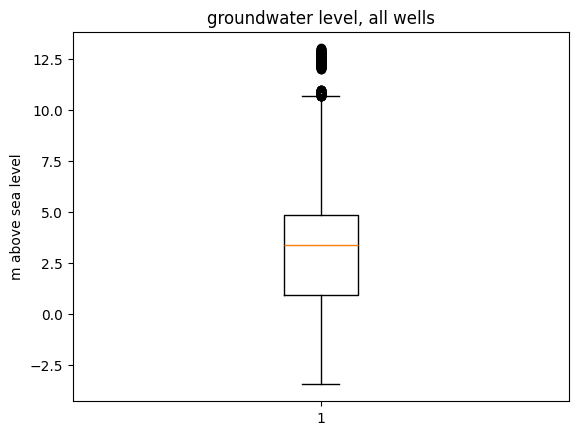

In [ ]:
plt.boxplot(df_monthly_fe[target])
plt.title('groundwater level, all wells')
plt.ylabel('m above sea level')
plt.show()

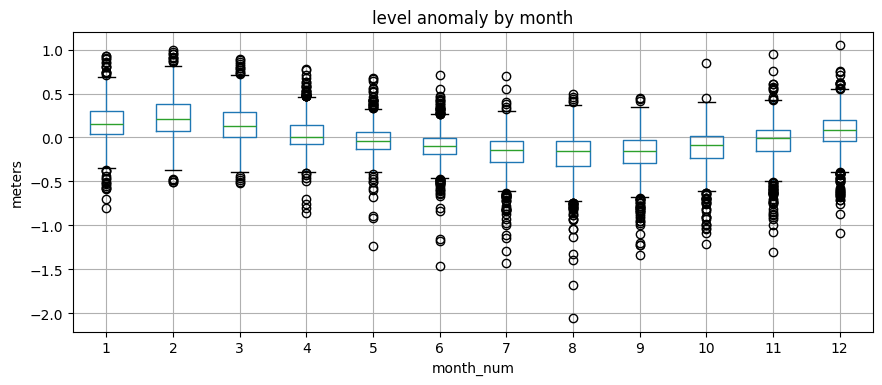

In [ ]:
# level vs each well's normal, by month
df_monthly_fe.boxplot(column='level_anomaly', by='month_num', figsize=(10, 4))
plt.title('level anomaly by month')
plt.suptitle('')
plt.ylabel('meters')
plt.show()

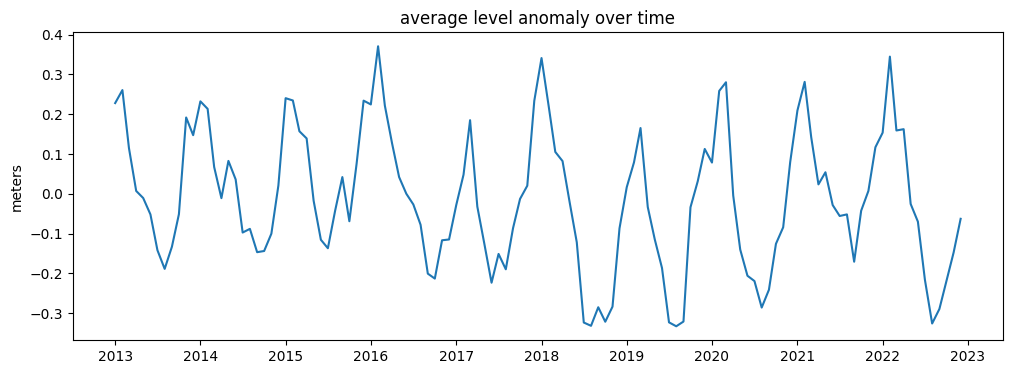

In [ ]:
# avg level over time, all wells
avg_level = df_monthly_fe.groupby('date')['level_anomaly'].mean()

plt.figure(figsize=(12, 4))
plt.plot(avg_level)
plt.title('average level anomaly over time')
plt.ylabel('meters')
plt.show()

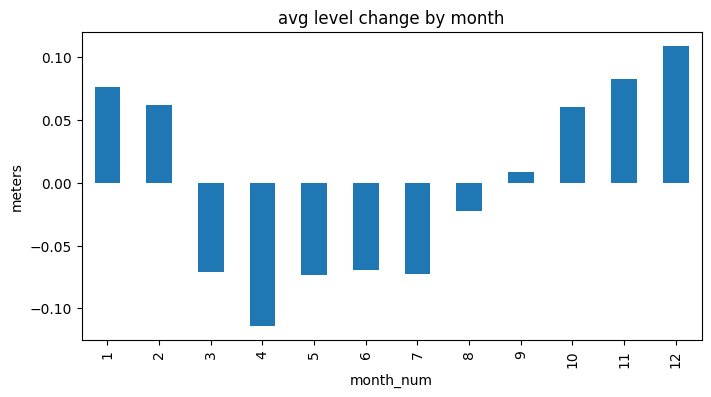

In [ ]:
#which months does the water go up or down?
df_monthly_fe = df_monthly_fe.copy()
df_monthly_fe['monthly_change'] = df_monthly_fe[target] - df_monthly_fe['level_lag_1']
change_by_month = df_monthly_fe.groupby('month_num')['monthly_change'].mean()

change_by_month.plot(kind='bar', figsize=(8, 4))
plt.title('avg level change by month')
plt.ylabel('meters')
plt.show()

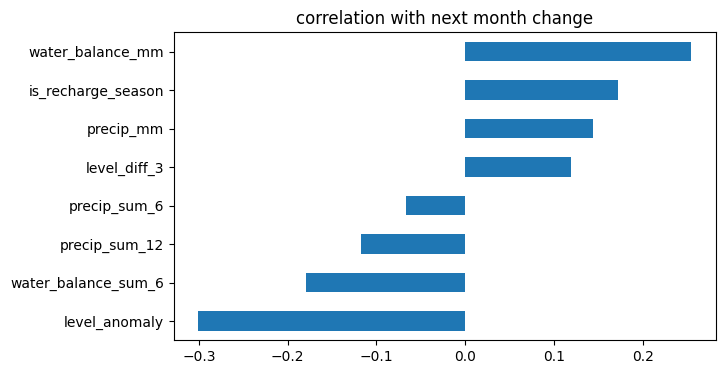

In [ ]:
# how the new features relate to next month's change
df_monthly_fe = df_monthly_fe.copy()
df_monthly_fe['next_change'] = df_monthly_fe.groupby('GROW_ID')[target].shift(-1) - df_monthly_fe[target]

new_features = ['precip_mm', 'water_balance_mm', 'precip_sum_6', 'precip_sum_12',
                'water_balance_sum_6', 'is_recharge_season', 'level_diff_3', 'level_anomaly']
corr = df_monthly_fe[new_features].corrwith(df_monthly_fe['next_change']).sort_values()

corr.plot(kind='barh', figsize=(7, 4))
plt.title('correlation with next month change')
plt.show()